## Remnants from precessing NRSur7dq4Remnants

In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")  # silence LAL warnings

# general modules
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
plt.rc('figure', figsize=(8, 5))
plt.rcParams.update({'text.usetex': True,'text.latex.preamble':r'\usepackage{amsmath}',
                     'font.family': 'serif','font.serif': ['Georgia'],'mathtext.fontset': 'cm',
                     'lines.linewidth': 1.8,'font.size': 18,'xtick.labelsize': 'large',
                     'ytick.labelsize': 'large','xtick.direction': 'in','ytick.direction': 'in',
                     'xtick.major.width': 1.4,'ytick.major.width': 1.4,'xtick.major.size': 5.,
                     'ytick.major.size': 5.,'ytick.right':True,'axes.labelsize': 'large',
                     'axes.titlesize': 'large','axes.grid': True,'grid.alpha': 0.5,
                     'lines.markersize': 12,'legend.borderpad': 0.2,'legend.fancybox': True,
                     'legend.fontsize': 15,'legend.framealpha': 0.7,'legend.handletextpad': 0.5,
                     'legend.labelspacing': 0.2,'legend.loc': 'best','savefig.bbox': 'tight',
                     'savefig.pad_inches': 0.05,'savefig.dpi': 80,'pdf.compression': 9})

import sys
sys.path.append("/Users/tousifislam/Research/projects/astro_projects/prec_hierarchical/gwGenealogy/")
import gwGenealogy

# import rit kick module
from gwGenealogy.remnants import bbh_final_state_precessing_NRSur7dq4Remnant
from gwGenealogy.remnants import bbh_final_kick_precessing_CLZM2007

Loaded NRSur7dq4Remnant fit.
Loaded NRSur3dq8Remnant fit.
Loaded NRSur7dq4EmriRemnant fit.


In [2]:
m1 = gwGenealogy.core.sample_powerlaw_1d(n_samples=1000, beta=-1.3, xmin=5, xmax=50, seed=40)
m2 = gwGenealogy.core.sample_powerlaw_1d(n_samples=1000, beta=-1.3, xmin=5, xmax=50, seed=50)
s1_vec, s2_vec = gwGenealogy.core.sample_isotropic_spins(n_samples=1000, chi_min=0, chi_max=1)
mf, chif, vf = bbh_final_state_precessing_NRSur7dq4Remnant(m1, m2, s1_vec, s2_vec)

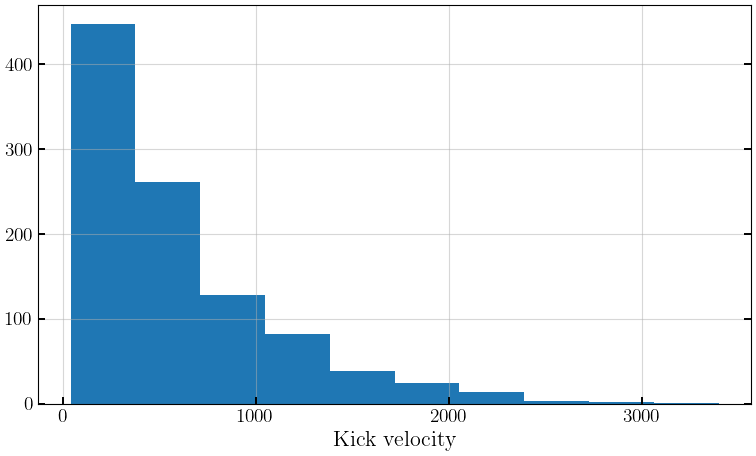

In [3]:
plt.hist(vf);
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Kick velocity', fontsize=16)
plt.tight_layout()
plt.show()

In [4]:
theta1, theta2, deltaphi, chi_primary, chi_secondary = gwGenealogy.core.spin_vectors_to_angles(m1, m2, s1_vec, s2_vec)
small_q = gwGenealogy.core.m1_m2_to_small_q(m1,m2)
vf_rit = bbh_final_kick_precessing_CLZM2007(theta1, theta2, deltaphi, small_q, chi_primary, chi_secondary, Theta=0)

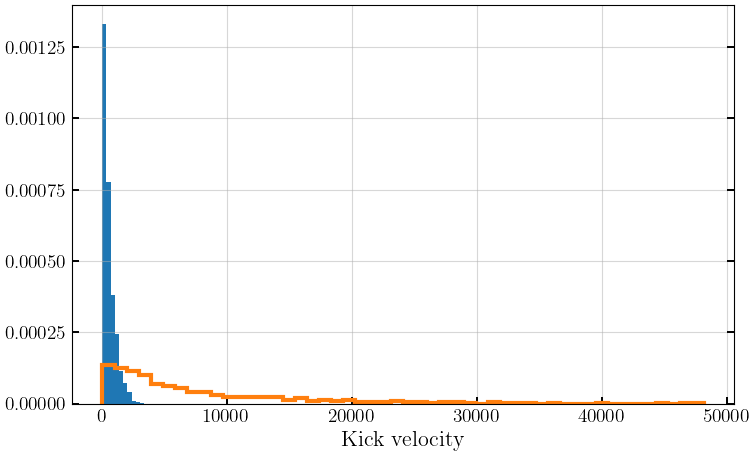

In [5]:
plt.hist(vf, density=True);
plt.hist(vf_rit, histtype='step', bins=50, lw=3, density=True);
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Kick velocity', fontsize=16)
plt.tight_layout()
plt.show()

In [6]:
sys.path.append("/Users/tousifislam/Research/projects/astro_projects/prec_hierarchical/precession/")
import precession

In [7]:
vf_rit_precession = precession.remnantkick(theta1, theta2, deltaphi, small_q, chi_primary, chi_secondary, kms=True)

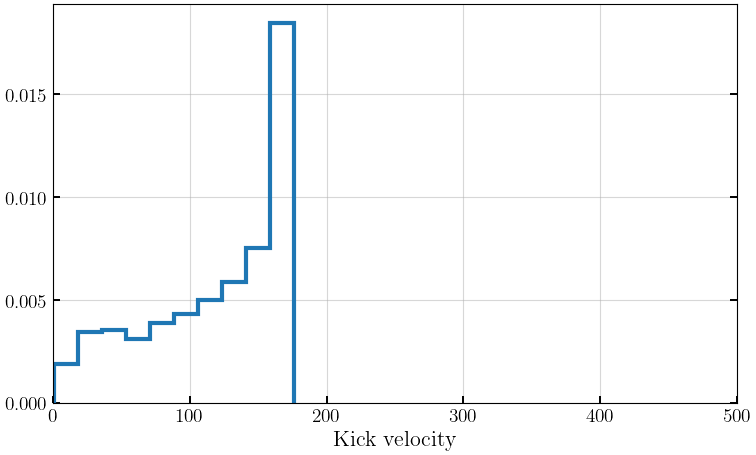

In [8]:
#plt.hist(vf, density=True);
#plt.hist(vf_rit, histtype='step', lw=3, density=True);
plt.hist(vf_rit_precession, histtype='step', lw=3, density=True);
plt.xlim(0, 500)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Kick velocity', fontsize=16)
plt.tight_layout()
plt.show()